## K-Means (Model)

*Segmantasyon Problemi'ni nasıl çözeriz sorusunu bir veri seti üzerinden anlatmaya çalışacağız. Veri setimiz ve çözmek istediğimiz problem şu şekilde:*

*ABD'nin çeşitli eyatlerini suç istatistiklerine göre kümelemek istiyoruz. Oluşturacağımız bu segmentlere göre eyatlere birtakım muamelelerde bulunmak istiyoruz. Örneğin taciz, tecavüz oranı yüksek bir eyalet için idam kararı alınıp bu kararı ilgili eyaletin meclisinden geçirip yürürlülüğe sokmak gibi. Veri setimiz de ABD'nin bütün eyaletlerinde işlenen çeşitli suçlara ilişkin istatistik bilgilerini içeriyor. İşte bu segmentasyon problemini el ile manuel bir şekilde çözmek yerine Veri Bilimi perspektifinden çözmeye uğraşacağız. Veri setimiz çok küçük fakat öğrenmek için ideal bir veri seti.*

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("USArrests.csv").copy()
df.head()

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [3]:
#Veri On Isleme

In [4]:
df.index = df.iloc[:,0]

In [5]:
df.index

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
       'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'],
      dtype='str', name='Unnamed: 0')

In [6]:
df.head()

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
Unnamed: 0,,,,,
Alabama,Alabama,13.2,236,58,21.2
Alaska,Alaska,10.0,263,48,44.5
Arizona,Arizona,8.1,294,80,31.0
Arkansas,Arkansas,8.8,190,50,19.5
California,California,9.0,276,91,40.6


In [7]:
df = df.iloc[:, 1:5]

In [8]:
df.head()

,Murder,Assault,UrbanPop,Rape
Unnamed: 0,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [9]:
df.index.name = None

In [10]:
df.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [11]:
#EDA

In [12]:
df.isnull().sum()

Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.4 KB


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


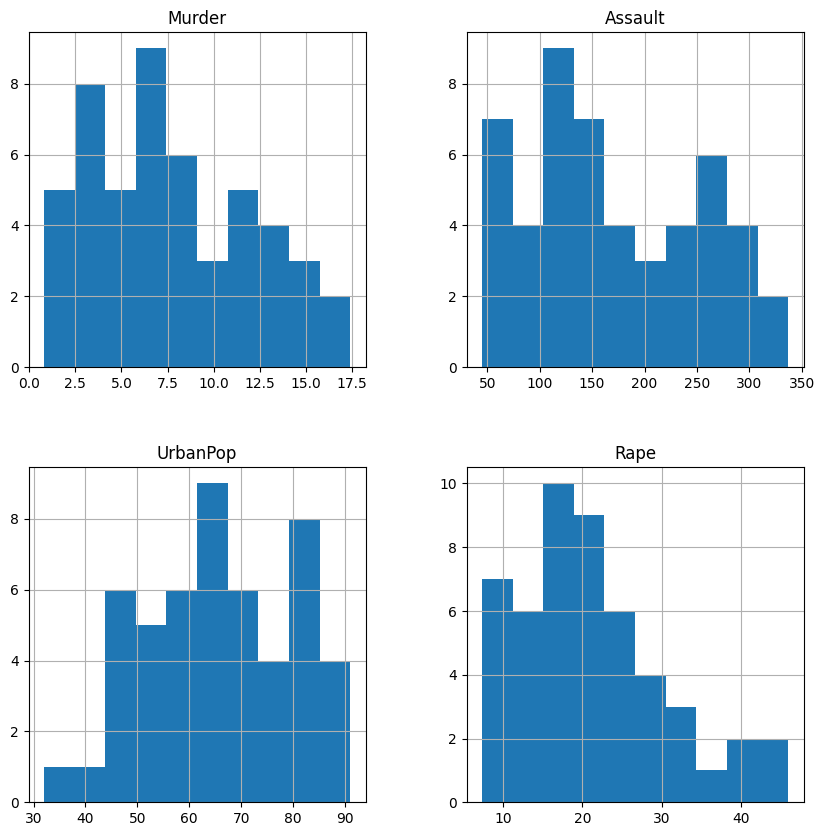

In [15]:
df.hist(figsize = (10,10));

In [16]:
#Model ve Gorsellestirme

In [17]:
kmeans = KMeans(n_clusters = 4)

In [18]:
kmeans.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 4,
 'n_init': 'auto',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [19]:
#model fit etme

In [20]:
k_fit = kmeans.fit(df)

In [21]:
k_fit.n_clusters

4

In [22]:
#her bir degiskenin her bir kume merkezine olan uzakligi

In [23]:
k_fit.cluster_centers_

array([[  4.16111111,  83.94444444,  57.77777778,  13.52777778],
       [ 12.13571429, 277.64285714,  68.78571429,  29.78571429],
       [  5.95454545, 152.        ,  74.27272727,  20.7       ],
       [ 11.3       , 209.71428571,  65.28571429,  24.77142857]])

In [24]:
#hangi eyalet hangi cluster'da ?

In [25]:
k_fit.labels_

array([3, 1, 1, 3, 1, 3, 0, 3, 1, 3, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 2, 1,
       0, 1, 2, 0, 0, 1, 0, 2, 1, 1, 1, 0, 2, 2, 2, 0, 2, 1, 0, 3, 3, 2,
       0, 2, 2, 0, 0, 2], dtype=int32)

In [26]:
#Gorsellestirme(2 boyut)

In [27]:
kmeans = KMeans(n_clusters = 2)
k_fit = kmeans.fit(df)n

In [28]:
kumeler = k_fit.labels_

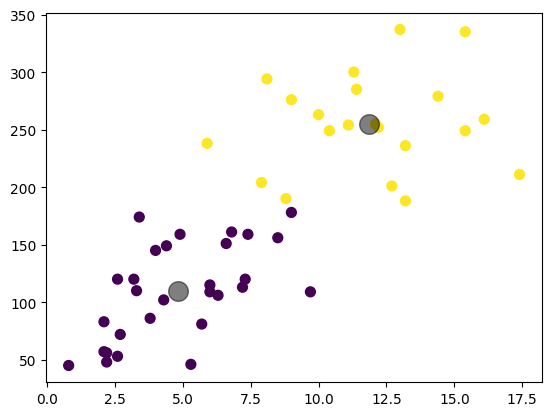

In [29]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c = kumeler, s = 50, cmap = "viridis");

merkezler = k_fit.cluster_centers_

plt.scatter(merkezler[:,0], merkezler[:,1], c = "black", s = 200, alpha = 0.5);

In [30]:
#Gorsellestirme(3 boyut)

In [31]:
from mpl_toolkits.mplot3d import Axes3D

In [32]:
kmeans = KMeans(n_clusters = 3)
k_fit = kmeans.fit(df)
kumeler = k_fit.labels_
merkezler = k_fit.cluster_centers_

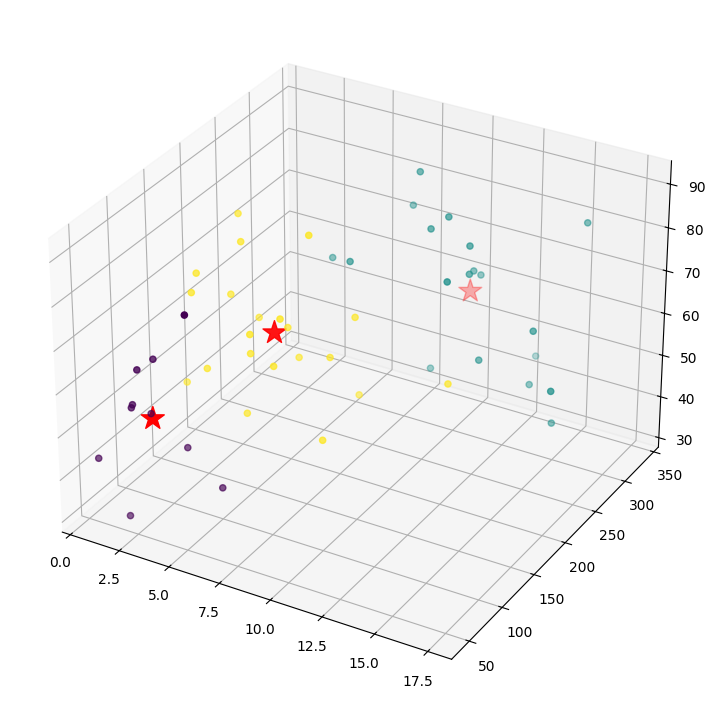

In [33]:
plt.rcParams['figure.figsize'] = (16,9)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

#veri noktalari
ax.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    df.iloc[:,2],
    c = kumeler
)

#kume merkezleri
ax.scatter(
    merkezler[:,0],
    merkezler[:,1],
    merkezler[:,2],
    s=300,
    c="red",
    marker="*"
)
plt.show()

In [34]:
#hangi eyalet hangi cluster'da dataframe olarak gosterimi

In [35]:
kmeans = KMeans(n_clusters = 3)
k_fit = kmeans.fit(df)
kumeler = k_fit.labels_

In [36]:
pd.DataFrame({"Eyaletler" : df.index, "Kumeler" : kumeler})[0:10]

,Eyaletler,Kumeler
0,Alabama,0
1,Alaska,0
2,Arizona,0
3,Arkansas,1
4,California,0
5,Colorado,0
6,Connecticut,1
7,Delaware,0
8,Florida,0
9,Georgia,0


## Model Tuning (Optimum Kume Sayisinin Belirlenmesi)

*K-Means'te temel amacımızın kümelerin kendi içerisinde benzerliğin maksimum, kümeler arası benzerliğin ise minimum olması gerektiğini ifade etmiştik. Bunu sağlayacak en optimum küme sayısını bulmaya odaklanalım.*

*Rastgele birtakım küme sayıları için hata kareler toplamı( burada SSD) bulup elde ettiğimiz değerlere göre en uygun küme sayısını belirlemeye çalışacağız. En çok kullanılan yöntem olan **Elbow** yöntemini kullanacağız.*

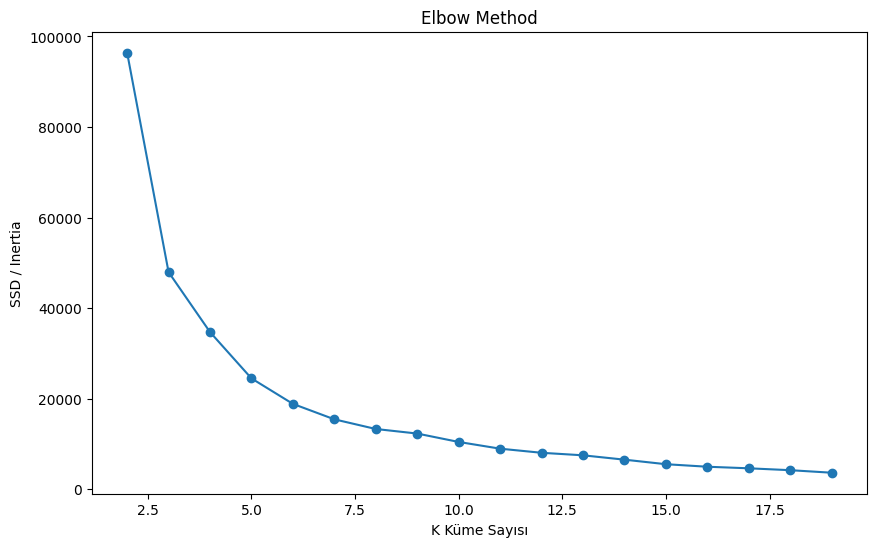

In [37]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ssd = []

K = range(2, 20)

#her bir k degeri icin model kurulumu
for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df)
    ssd.append(model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, ssd, marker="o")
plt.xlabel("K Küme Sayısı")
plt.ylabel("SSD / Inertia")
plt.title("Elbow Method")
plt.show()

*Küme sayısı gözlem birimi sayısına eşit olduğunda SSD değerinin sıfır olduğunu görüyoruz. Bu normal çünkü her bir gözlem biriminin kendi kümesi var ve bu gözlem birimleri tam da kümenin merkezinde. Distance değeri her bir küme değeri için sıfır olur.*

*Burada segment sayısı grafiğe bakılarak verilmez, iş bilgisine, iş problemine bakılarak verilir. Burada elde ettiğimiz grafik sadece bir karar destek mekanizmasından ibarettir.*

*Grafikte kırılımın küme sayısı 4 olunca başladığını görebiliyoruz. Yani kümeler arası homojenliğin, kümeler arası heterojenliğin arttığı nokta n = 4'ten itibaren diyebiliriz.*

In [38]:
#final model

In [39]:
kmeans = KMeans(n_clusters  = 4)
k_fit = kmeans.fit(df)
kumeler = k_fit.labels_

In [40]:
pd.DataFrame({"Eyaletler" : df.index, "Kumeler" : kumeler})[0:10]

,Eyaletler,Kumeler
0,Alabama,3
1,Alaska,1
2,Arizona,1
3,Arkansas,3
4,California,1
5,Colorado,3
6,Connecticut,2
7,Delaware,3
8,Florida,1
9,Georgia,3
